## STEP 1 — Install and Import All Libraries

Before we start building our Handwritten Digit Recognition project, we need to set up our environment by installing (if necessary) and importing the required Python libraries. These libraries provide the tools and functionalities we'll use throughout the project.

Here's what each library does:

*   **TensorFlow and Keras**: These are powerful open-source machine learning frameworks developed by Google. Keras is a high-level API that runs on top of TensorFlow, making it easier and faster to build, train, and evaluate deep learning models like the Convolutional Neural Network (CNN) we'll be using.
*   **NumPy**: This is a fundamental library for numerical computing in Python. It provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays. We'll use it for data manipulation and calculations.
*   **Matplotlib**: A comprehensive library for creating static, animated, and interactive visualizations in Python. We'll use Matplotlib to plot graphs (like training history) and display images (like the MNIST digits).
*   **Seaborn**: Built on top of Matplotlib, Seaborn is a data visualization library that provides a high-level interface for drawing attractive and informative statistical graphics. We'll use it specifically for visualizing the confusion matrix as a heatmap.
*   **Scikit-learn (sklearn)**: A popular machine learning library that offers various classification, regression, and clustering algorithms. We'll use it for evaluating our model's performance, particularly for generating the confusion matrix and classification report.
*   **Warnings**: This built-in Python module is used to control how warning messages are handled. We'll use it to filter out unnecessary warnings to keep our output clean.

In [ ]:
# Install necessary libraries (if not already installed). Uncomment the line below if you need to install them.
# !pip install tensorflow keras numpy matplotlib seaborn scikit-learn

# Import the NumPy library for numerical operations, especially with arrays.
import numpy as np
# Import Matplotlib's pyplot module for creating plots and visualizing images.
import matplotlib.pyplot as plt
# Import Seaborn for enhanced data visualizations, particularly for statistical plots like heatmaps.
import seaborn as sns
# Import TensorFlow, the core open-source machine learning platform.
import tensorflow as tf
# Import Keras, the high-level API for building and training deep learning models, integrated with TensorFlow.
from tensorflow import keras
# Import the layers module from Keras to define different types of neural network layers.
from tensorflow.keras import layers
# Import to_categorical from Keras utilities for one-hot encoding our labels.
from tensorflow.keras.utils import to_categorical
# Import classification_report and confusion_matrix from scikit-learn for model evaluation metrics.
from sklearn.metrics import classification_report, confusion_matrix
# Import the warnings module to manage warning messages.
import warnings
# Filter out warnings to keep the output cleaner, especially during model training.
warnings.filterwarnings('ignore')

# Print the installed TensorFlow version to ensure compatibility and for reference.
print("TensorFlow version:", tf.__version__)
# Confirm that all specified libraries have been imported successfully.
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


## STEP 2 — Load the MNIST Dataset

The MNIST (Modified National Institute of Standards and Technology) dataset is a widely used dataset for training image processing systems. It's often called the "hello world" of deep learning for computer vision. It consists of a large collection of handwritten digits. Here's a breakdown:

*   **What is MNIST dataset?** It comprises 70,000 grayscale images of handwritten digits, from 0 to 9.
*   **Dataset Split**: The dataset is conveniently split into two main parts:
    *   **60,000 images for training (X_train, y_train)**: These images are used to train our Convolutional Neural Network model. The model learns to recognize patterns from these examples.
    *   **10,000 images for testing (X_test, y_test)**: These images are completely unseen by the model during training. They are used to evaluate how well our trained model generalizes to new, real-world data.
*   **Image Characteristics**: Each image in the dataset is a 28x28 pixel grayscale image. Grayscale means each pixel has a single intensity value, typically ranging from 0 (black) to 255 (white).
*   **Built-in to Keras**: One of the convenient aspects of the MNIST dataset is that it comes pre-loaded with Keras. This means you don't need to manually download any files; Keras handles the data loading directly from its internal resources.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Shape of X_train (training images): (60000, 28, 28)
Shape of y_train (training labels): (60000,)
Shape of X_test (testing images): (10000, 28, 28)
Shape of y_test (testing labels): (10000,)
Total number of training samples: 60000
Total number of testing samples: 10000
Minimum pixel value: 0
Maximum pixel value: 255


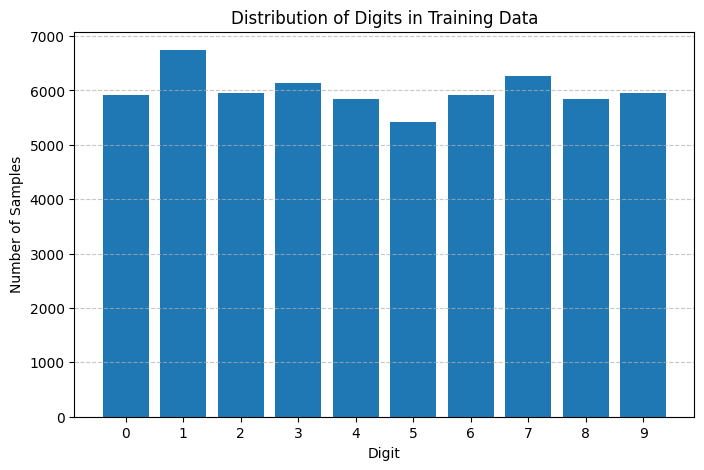

In [ ]:
# Import the mnist dataset directly from Keras datasets.
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset. It automatically splits into training and testing sets.
# X_train and X_test contain the image data (pixel values).
# y_train and y_test contain the corresponding labels (the actual digit).
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Print the shape of the training features (images) to see the number of samples and image dimensions.
print(f"Shape of X_train (training images): {X_train.shape}")
# Print the shape of the training labels to see the number of labels.
print(f"Shape of y_train (training labels): {y_train.shape}")
# Print the shape of the testing features (images).
print(f"Shape of X_test (testing images): {X_test.shape}")
# Print the shape of the testing labels.
print(f"Shape of y_test (testing labels): {y_test.shape}")

# Calculate and print the total number of training samples.
print(f"Total number of training samples: {X_train.shape[0]}")
# Calculate and print the total number of testing samples.
print(f"Total number of testing samples: {X_test.shape[0]}")

# Print the minimum pixel value found in the training dataset. (Should be 0 as images are grayscale).
print(f"Minimum pixel value: {np.min(X_train)}")
# Print the maximum pixel value found in the training dataset. (Should be 255 for 8-bit grayscale images).
print(f"Maximum pixel value: {np.max(X_train)}")

# Create a figure and an axes for the bar chart.
plt.figure(figsize=(8, 5))
# Use numpy's bincount to count the occurrences of each digit in the training labels.
# Convert the bincount result to a list for plotting.
class_counts = np.bincount(y_train)
# Create a bar chart using matplotlib to visualize the distribution of digits.
plt.bar(range(10), class_counts, tick_label=range(10))
# Set the title of the plot.
plt.title('Distribution of Digits in Training Data')
# Set the label for the x-axis.
plt.xlabel('Digit')
# Set the label for the y-axis.
plt.ylabel('Number of Samples')
# Add a grid for better readability.
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Display the plot.
plt.show()

## STEP 3 — Explore and Visualize the Data

Data exploration is a crucial initial phase in any machine learning project. It involves examining the dataset's characteristics, understanding its structure, and identifying patterns or anomalies. Visualizing the data, especially images, helps us gain intuitive insights into what our model will be working with.

**Why is data exploration important?**

1.  **Understanding the Data**: It gives us a first-hand look at the actual images our model will learn from. This helps confirm that the data is as expected (e.g., handwritten digits, grayscale, 28x28 pixels).
2.  **Identifying Issues**: We can spot potential problems like corrupted images, extreme pixel values, or class imbalances (though we already checked class distribution in the previous step).
3.  **Guiding Preprocessing**: Understanding the raw data informs our choices for preprocessing steps, such as normalization or reshaping, to make the data suitable for our neural network.
4.  **Building Intuition**: Seeing the digits helps us appreciate the challenge of recognizing variations in handwriting and reinforces why a powerful model like a CNN is needed.

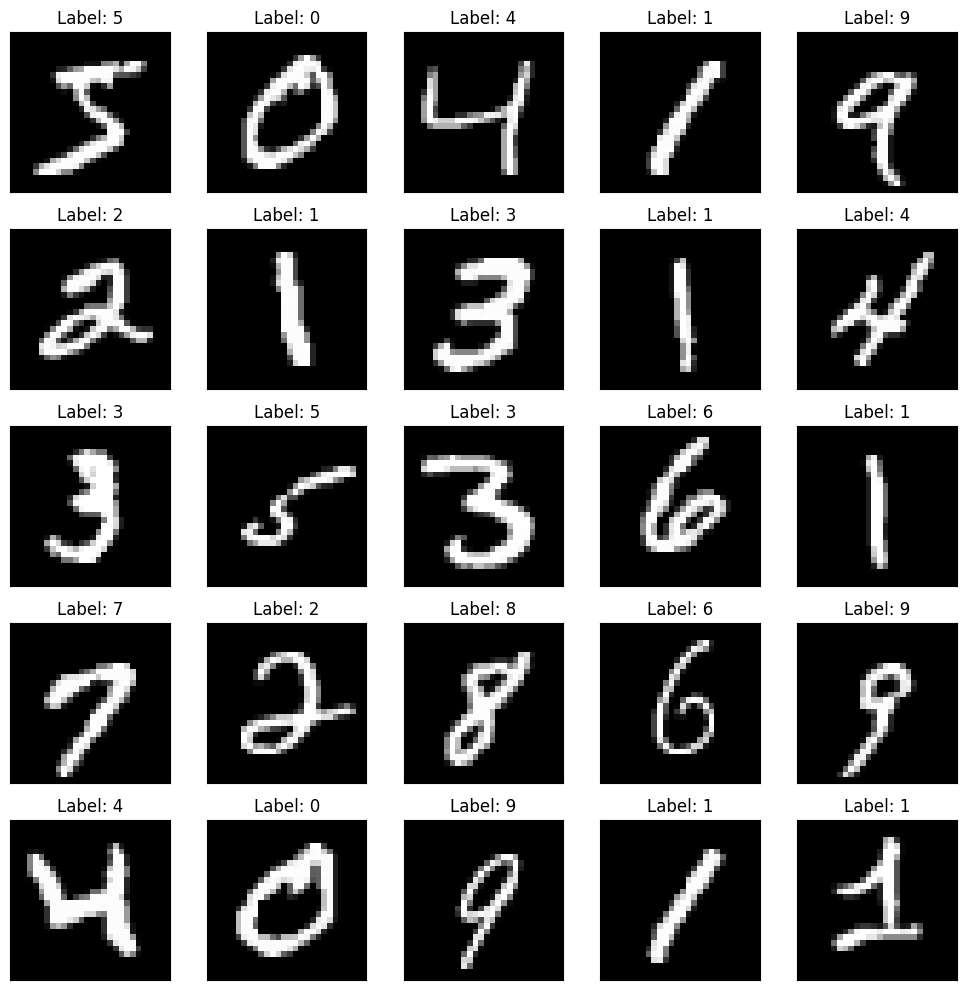

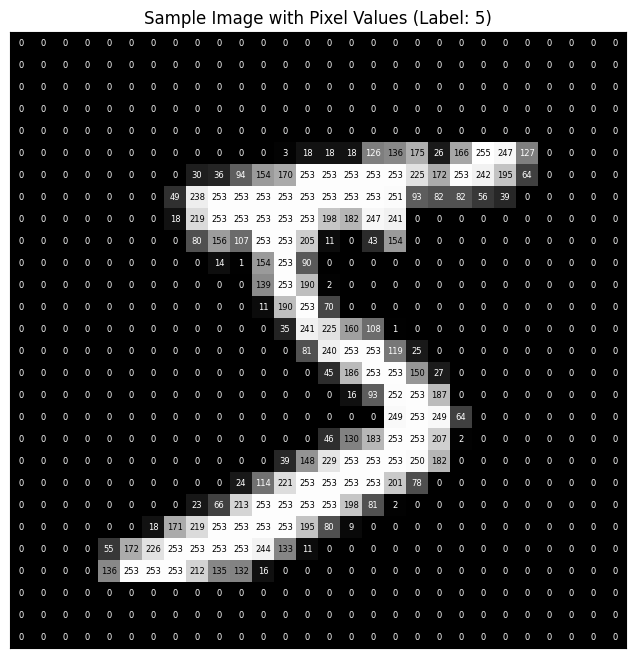

In [ ]:
# Display a 5x5 grid of random training samples with their labels.
plt.figure(figsize=(10, 10)) # Set the overall size of the figure for the grid.

# Loop 25 times to display 25 random images.
for i in range(25):
    plt.subplot(5, 5, i + 1) # Create a 5x5 grid of subplots and select the current one.
    plt.xticks([]) # Hide x-axis ticks.
    plt.yticks([]) # Hide y-axis ticks.
    plt.grid(False) # Hide the grid lines.

    # Display the image. X_train contains the pixel data, cmap='gray' shows it in grayscale.
    plt.imshow(X_train[i], cmap='gray')

    # Set the title of the image to its corresponding label.
    # y_train[i] gives the numerical label (0-9) for the i-th image.
    plt.title(f"Label: {y_train[i]}")
plt.tight_layout() # Adjust subplot parameters for a tight layout.
plt.show() # Display the plot.

# Display one single image zoomed in with pixel values printed as a grid.
plt.figure(figsize=(8, 8)) # Set the size of the figure for the single image.
# Display the first image from the training set in grayscale.
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Sample Image with Pixel Values (Label: {y_train[0]})") # Set the title including its label.

# Loop through each pixel to print its value on the image.
for i in range(X_train[0].shape[0]): # Iterate over rows (height).
    for j in range(X_train[0].shape[1]): # Iterate over columns (width).
        # Get the pixel value. X_train is (num_samples, height, width).
        pixel_value = X_train[0][i, j]
        # Annotate the image with the pixel value.
        # Text color is black for light backgrounds, white for dark backgrounds.
        plt.text(j, i, pixel_value, ha="center", va="center", color="white" if pixel_value < 128 else "black", fontsize=6)

plt.xticks([]) # Hide x-axis ticks.
plt.yticks([]) # Hide y-axis ticks.
plt.grid(False) # Hide the grid lines.
plt.show()

## STEP 4 — Preprocess the Data

Preprocessing is a critical step in preparing our data for a neural network model. It transforms the raw data into a format that the model can effectively learn from. For image data like MNIST, the main preprocessing steps are normalization, reshaping, and one-hot encoding.

*   **Why we normalize pixel values (divide by 255.0)**:
    *   **Original Range**: Pixel values in our grayscale images range from 0 (black) to 255 (white).
    *   **Normalized Range**: Dividing by 255.0 scales these values down to a range of 0.0 to 1.0.
    *   **Benefits**: Normalization helps neural networks train more efficiently and converge faster. It prevents larger input values from creating larger weight updates, which can lead to unstable training. It also helps in avoiding issues like vanishing or exploding gradients.

*   **Why we reshape to (28, 28, 1) for CNN input**:
    *   **Original Shape**: Our current `X_train` and `X_test` arrays have a shape of `(num_samples, 28, 28)`. This means each image is a 28x28 matrix of pixel intensities.
    *   **CNN Expectation**: Convolutional Neural Networks (CNNs) in Keras typically expect input images to have a channel dimension. For grayscale images, this channel dimension is 1 (indicating a single color channel, unlike RGB images which have 3 channels).
    *   **Reshaped Shape**: We will reshape our data to `(num_samples, 28, 28, 1)`. The `-1` in `reshape(-1, 28, 28, 1)` automatically infers the number of samples.

*   **Why we one-hot encode labels using `to_categorical`**:
    *   **Original Labels**: Our `y_train` and `y_test` currently contain integer labels (e.g., `3`, `7`, `0`). These are called categorical labels.
    *   **Neural Network Output**: For a classification task with multiple classes (like 10 digits), the output layer of our neural network will typically have 10 neurons, each representing the probability that the input image belongs to a particular digit class.
    *   **One-Hot Encoding**: One-hot encoding converts a single integer label into a binary vector where only one element is 'hot' (1) and the others are 'cold' (0). For example:
        *   If the digit is `3`, the one-hot encoded label will be `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`.
        *   If the digit is `7`, it will be `[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]`.
    *   **Benefits**: This format is ideal for training with `categorical_crossentropy` loss function, which our model will use, as it calculates the difference between the predicted probability distribution and the true one-hot encoded distribution.

```
Original Label (e.g., for digit 3):    3

One-Hot Encoded Label (10 classes):   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
                                       ^  ^  ^  ^
                                       |  |  |  |
                                       0  1  2  3 (index for digit 3 is 1)
```

In [ ]:
# Import the mnist dataset directly from Keras datasets to get fresh data.
from tensorflow.keras.datasets import mnist

# Reload the MNIST dataset to ensure y_train and y_test are in their original integer format.
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Normalize pixel values from [0, 255] to [0.0, 1.0].
# This step is crucial for helping the neural network converge faster and perform better.
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0
print("Pixel values normalized to [0.0, 1.0].")

# Reshape the images to add a channel dimension.
# CNNs typically expect input in the format (batch_size, height, width, channels).
# For grayscale images, the channel dimension is 1.
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
print("Images reshaped for CNN input.")

# One-hot encode the labels.
# This converts integer labels (0-9) into binary vectors suitable for categorical cross-entropy loss.
# For example, digit 3 becomes [0,0,0,1,0,0,0,0,0,0]. We have 10 classes (digits 0-9).
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)
print("Labels one-hot encoded.")

# Print shapes after preprocessing to confirm the transformations.
print(f"Shape of X_train after preprocessing: {X_train.shape}")
print(f"Shape of y_train after preprocessing: {y_train.shape}")
print(f"Shape of X_test after preprocessing: {X_test.shape}")
print(f"Shape of y_test after preprocessing: {y_test.shape}")

# Print one sample one-hot encoded label and show which digit it represents.
# np.argmax is used to find the index of the '1' in the one-hot vector, which corresponds to the digit.
print(f"\nSample of one-hot encoded y_train label (first image): {y_train[0]}")
print(f"This corresponds to digit: {np.argmax(y_train[0])}")

Pixel values normalized to [0.0, 1.0].
Images reshaped for CNN input.
Labels one-hot encoded.
Shape of X_train after preprocessing: (60000, 28, 28, 1)
Shape of y_train after preprocessing: (60000, 10)
Shape of X_test after preprocessing: (10000, 28, 28, 1)
Shape of y_test after preprocessing: (10000, 10)

Sample of one-hot encoded y_train label (first image): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
This corresponds to digit: 5


## STEP 5 — Build the CNN Model

Now that our data is prepared, it's time to build the core of our Handwritten Digit Recognition system: a Convolutional Neural Network (CNN). CNNs are a class of deep neural networks, most commonly applied to analyzing visual imagery.

**What is a CNN in simple words?**

Imagine you're trying to identify a handwritten digit. You don't look at individual pixels; instead, you look for features like curves, lines, and loops. A CNN works similarly: it learns to identify increasingly complex patterns (features) in images by passing them through several specialized layers.

**Here's what each layer in our CNN does:**

*   **INPUT IMAGE (28x28x1)**:
    *   This is our preprocessed image: 28 pixels wide, 28 pixels high, and 1 channel (because it's grayscale).
    *   It's the raw data fed into the network.
    ↓
*   **Conv2D (Convolutional Layer)**:
    *   **Purpose**: This layer applies filters (small matrices) across the image to detect specific features like edges, corners, or textures.
    *   **Activation ('relu')**: Rectified Linear Unit activation function. It introduces non-linearity, allowing the model to learn more complex relationships. It simply outputs the input directly if it's positive, otherwise, it outputs zero.
    *   **Input Shape**: The first `Conv2D` layer needs `input_shape=(28,28,1)` to know the dimensions of the images it will process.
    *   **Output**: Produces feature maps highlighting where these patterns are found.
    ↓
*   **BatchNormalization**:
    *   **Purpose**: This layer normalizes the activations of the previous layer for each batch, meaning it rescales the output of the convolutional layer to have a mean of 0 and a standard deviation of 1.
    *   **Benefit**: It helps stabilize and speed up the training process by reducing internal covariate shift, allowing the use of higher learning rates and making the model less sensitive to initialization.
    ↓
*   **MaxPooling2D**:
    *   **Purpose**: This layer reduces the spatial dimensions (width and height) of the feature maps, effectively downsampling the image.
    *   **Benefit**: It helps in making the model more robust to small shifts or distortions in the input image and reduces the number of parameters, making computation faster.
    ↓
*   **Conv2D (another Convolutional Layer)**:
    *   **Purpose**: Similar to the first `Conv2D` layer, but now it operates on the downsampled feature maps. It can learn to detect more complex and abstract features by combining the simpler features detected by the previous layers.
    ↓
*   **BatchNormalization**:
    *   **Purpose**: Normalizes activations to stabilize training.
    ↓
*   **MaxPooling2D**:
    *   **Purpose**: Further reduces spatial dimensions.
    ↓
*   **Conv2D (third Convolutional Layer)**:
    *   **Purpose**: Detects even more intricate patterns.
    ↓
*   **Flatten**:
    *   **Purpose**: Converts the 2D feature maps (output from the last `MaxPooling2D` layer) into a 1D vector.
    *   **Why**: This is necessary to feed the data into the subsequent fully connected (Dense) layers.
    ↓
*   **Dense (Fully Connected Layer)**:
    *   **Purpose**: A standard neural network layer where every neuron is connected to every neuron in the previous layer. It takes the flattened features and learns higher-level non-linear combinations.
    *   **Activation ('relu')**: Continues to introduce non-linearity.
    ↓
*   **Dropout**:
    *   **Purpose**: A regularization technique where randomly selected neurons are ignored (set to zero) during training.
    *   **Benefit**: Prevents the model from becoming too reliant on specific neurons, thereby reducing overfitting and improving generalization to unseen data.
    ↓
*   **Dense (Output Layer)**:
    *   **Purpose**: This is the final layer of our network. It has 10 neurons, one for each possible digit (0-9).
    *   **Activation ('softmax')**: The softmax activation function converts the raw outputs of the neurons into a probability distribution. The sum of probabilities for all 10 digits will be 1, indicating the model's confidence for each digit.
    *   **Output**: The neuron with the highest probability is the model's prediction.

In [ ]:
import tensorflow.keras.backend as K
# Import the Sequential model class from Keras.
from tensorflow.keras.models import Sequential
# Import different types of layers we'll use in our CNN.
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Initialize a Sequential model, which is a linear stack of layers.
model = Sequential([
    # First Convolutional Layer:
    # 32 filters (feature detectors), each 3x3 pixels.
    # 'relu' activation for non-linearity.
    # input_shape=(28,28,1) specifies the dimensions of our input images (28x28 pixels, 1 color channel).
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Batch Normalization: Helps in stabilizing and speeding up training.
    BatchNormalization(),
    # First MaxPooling Layer:
    # Reduces the spatial dimensions (height and width) by 2x2, taking the maximum value.
    MaxPooling2D((2, 2)),

    # Second Convolutional Layer:
    # 64 filters, each 3x3 pixels, 'relu' activation.
    # This layer learns more complex features from the downsampled output of the previous layer.
    Conv2D(64, (3, 3), activation='relu'),
    # Batch Normalization again.
    BatchNormalization(),
    # Second MaxPooling Layer:
    # Further reduces spatial dimensions.
    MaxPooling2D((2, 2)),

    # Third Convolutional Layer:
    # 128 filters, each 3x3 pixels, 'relu' activation.
    Conv2D(128, (3, 3), activation='relu'),

    # Flatten Layer:
    # Converts the 2D feature maps from the last Conv2D layer into a 1D vector.
    # This prepares the data for the fully connected (Dense) layers.
    Flatten(),

    # First Dense (Fully Connected) Layer:
    # 256 neurons, 'relu' activation.
    # This layer processes the flattened features to learn high-level patterns.
    Dense(256, activation='relu'),
    # Dropout Layer:
    # Randomly sets 50% of the neurons to zero during training.
    # This helps prevent overfitting by forcing the network to learn more robust features.
    Dropout(0.5),

    # Output Dense Layer:
    # 10 neurons, one for each digit (0-9).
    # 'softmax' activation outputs a probability distribution over the 10 classes,
    # indicating the likelihood of the image belonging to each digit.
    Dense(10, activation='softmax')
])

# Print a summary of the model's architecture.
# This shows the layer names, their output shapes, and the number of parameters.
print("Model Architecture Summary:")
model.summary()

# Calculate and print the total number of trainable parameters in the model.
# This indicates the complexity of the model and how many weights it needs to learn.
total_trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
print(f"\nTotal number of trainable parameters: {total_trainable_params}")

Model Architecture Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,794 (1.49 MB)

 Trainable params: 390,602 (1.49 MB)

 Non-trainable params: 192 (768.00 B)


Total number of trainable parameters: 390602


### Understanding the Model Summary Output

The `model.summary()` output provides a detailed overview of your neural network's architecture, helping you understand its structure and complexity. Let's break down each column:

*   **Layer (type)**: This column lists the type of each layer in your model (e.g., `Conv2D`, `BatchNormalization`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout`). It shows the sequence in which data flows through the network.

*   **Output Shape**: This indicates the shape of the data after it passes through each layer. The `(None, ...)` part means the batch size can be anything. For example:
    *   `(None, 26, 26, 32)` for a `Conv2D` layer means it outputs a batch of images, each 26x26 pixels, with 32 feature maps (channels).
    *   `(None, 1152)` for a `Flatten` layer means it has converted the 2D feature maps into a 1D vector of 1152 elements.
    *   `(None, 10)` for the final `Dense` layer means it outputs a vector of 10 probabilities for each image in the batch (one for each digit 0-9).

*   **Param #**: This is one of the most important columns, as it shows the number of **trainable parameters** (weights and biases) in each layer. These are the values that the model learns during training.
    *   For `Conv2D` layers, parameters come from the filters (kernel weights) and biases.
    *   For `BatchNormalization` layers, parameters include scale (gamma) and shift (beta) values, as well as non-trainable mean and variance.
    *   For `MaxPooling2D` layers, the parameter count is `0` because they perform a fixed operation (downsampling) and don't have any learned weights.
    *   For `Flatten` layers, the parameter count is `0` as they simply rearrange the data.
    *   For `Dense` layers, parameters come from the connections between neurons and the biases.

*   **Total params**: The sum of all parameters in the model (trainable and non-trainable).

*   **Trainable params**: The number of parameters that will be adjusted during the training process. This is the value that directly contributes to the model's learning capacity.

*   **Non-trainable params**: Parameters that are not updated during training (e.g., population mean and variance in Batch Normalization layers if they are frozen, or values from pre-trained layers that are not fine-tuned).

## STEP 6 — Compile the Model

Before we can train our neural network, we need to **compile** it. This step configures the model for training by specifying the optimizer, loss function, and metrics it will use.

*   **What is an optimizer (Adam)?**
    *   The optimizer is the algorithm used to adjust the weights of the neural network during training. Its goal is to minimize the loss function.
    *   **Adam (Adaptive Moment Estimation)** is a popular and efficient optimizer that adapts the learning rate for each parameter, making it suitable for a wide range of deep learning problems. It's often chosen for its good performance and ease of use.

*   **What is a loss function (categorical_crossentropy)?**
    *   The loss function (also called objective function) quantifies how accurate our model is at predicting the correct class. It measures the discrepancy between the model's predicted probabilities and the true labels.
    *   **Categorical Crossentropy** is used for multi-class classification problems where the labels are one-hot encoded (which we did in Step 4). It penalizes the model based on how confident it is about incorrect predictions.

*   **What is a metric (accuracy)?**
    *   Metrics are used to monitor the training and testing steps and evaluate the performance of the model. Unlike the loss function, metrics are for human understanding.
    *   **Accuracy** is simply the proportion of correctly classified images. For a digit recognition task, it tells us how many digits the model predicted correctly out of the total.

*   **What are callbacks and why we use them?**
    *   Callbacks are functions that are executed at certain stages of the training procedure (e.g., at the end of each epoch). They allow us to add custom behavior to the training process.
    *   **`ReduceLROnPlateau`**: This callback monitors a quantity (e.g., validation accuracy) and if it stops improving for a certain number of epochs (`patience`), the learning rate will be reduced. This helps the model to converge better by taking smaller steps when it's close to the optimal solution.
    *   **`EarlyStopping`**: This callback stops training early if the monitored quantity (e.g., validation loss) has stopped improving for a specified number of epochs (`patience`). This prevents overfitting and saves computational resources by stopping training once the model's performance on unseen data starts to degrade.

In [ ]:
# Import optimizers and callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K

# Compile the model:
# The optimizer 'adam' is chosen for its efficiency in updating model weights.
# The loss function 'categorical_crossentropy' is used because our labels are one-hot encoded.
# 'accuracy' is the metric we'll use to evaluate the model's performance.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define Callbacks:

# 1. ReduceLROnPlateau: Reduces the learning rate when a metric (val_accuracy) has stopped improving.
#    monitor='val_accuracy': The metric to monitor.
#    factor=0.5: New learning rate will be old_lr * 0.5.
#    patience=3: Number of epochs with no improvement after which learning rate will be reduced.
#    min_lr=0.00001: The lower bound on the learning rate.
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, min_lr=0.00001, verbose=1)

# 2. EarlyStopping: Stops training when a monitored metric (val_loss) has stopped improving.
#    monitor='val_loss': The metric to monitor.
#    patience=5: Number of epochs with no improvement after which training will be stopped.
#    restore_best_weights=True: Restores model weights from the epoch with the best value of the monitored metric.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print("Model compiled successfully with Adam optimizer, Categorical Crossentropy loss, and Accuracy metric.")
print("Callbacks (ReduceLROnPlateau and EarlyStopping) have been defined.")

Model compiled successfully with Adam optimizer, Categorical Crossentropy loss, and Accuracy metric.
Callbacks (ReduceLROnPlateau and EarlyStopping) have been defined.


## STEP 7 — Train the Model

Training is the core process where our CNN learns to recognize patterns in the handwritten digits. During training, the model iteratively adjusts its internal weights and biases to minimize the loss function, thereby improving its accuracy.

*   **What is an epoch?**
    *   An epoch represents one complete pass through the entire training dataset. In each epoch, the model sees every training image once.
    *   Running multiple epochs allows the model to refine its understanding of the data and improve its performance over time. However, too many epochs can lead to overfitting.

*   **What is batch size?**
    *   Instead of updating the model's weights after every single image, training is done in smaller subsets of the data called 'batches'.
    *   `batch_size=64` means the model processes 64 images at a time, calculates the average loss for that batch, and then updates its weights.
    *   Using batches makes training more computationally efficient and helps in stabilizing the learning process compared to updating after each image.

*   **What is validation split?**
    *   During training, it's crucial to monitor how well our model performs on data it hasn't seen yet to ensure it generalizes well (doesn't just memorize the training data).
    *   `validation_split=0.1` means 10% of the `X_train` and `y_train` data will be set aside and used as a validation set. The model will not train on this data, but its performance will be evaluated on it after each epoch.
    *   This helps us track for signs of overfitting: if the model performs well on training data but poorly on validation data, it's overfitting.

*   **What overfitting means and how dropout and early stopping prevent it?**
    *   **Overfitting**: This occurs when a model learns the training data too well, including its noise and outliers, making it perform poorly on new, unseen data.
    *   **Dropout**: As explained in Step 5, dropout randomly deactivates a percentage of neurons during training. This forces the network to learn more robust features and prevents it from relying too heavily on any single neuron or specific patterns, thus reducing overfitting.
    *   **Early Stopping**: As explained in Step 6, this callback monitors the model's performance on the validation set. If the validation performance (e.g., validation loss) stops improving for a specified number of epochs (`patience`), training is halted. This prevents the model from continuing to train and potentially overfitting the training data.

In [ ]:
# Train the model:
# X_train, y_train: Training data and labels.
# epochs=20: The number of complete passes through the training dataset. We start with 20, but early stopping might halt it sooner.
# batch_size=64: The number of samples per gradient update.
# validation_split=0.1: 10% of the training data will be used for validation to monitor performance and detect overfitting.
# callbacks=[reduce_lr, early_stopping]: Apply the defined learning rate reduction and early stopping mechanisms.
# verbose=1: Displays a progress bar and training metrics for each epoch.
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, early_stopping],
    verbose=1
)

# Print confirmation that training is complete.
print("\nTraining Complete!")

# Get the best validation accuracy achieved during training
# The EarlyStopping callback restores the best weights, so we can check history for the epoch with the best val_accuracy.
best_val_accuracy = max(history.history['val_accuracy'])
print(f"Best Validation Accuracy Achieved: {best_val_accuracy:.4f}")

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 90ms/step - accuracy: 0.9572 - loss: 0.1403 - val_accuracy: 0.9847 - val_loss: 0.0552 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 88ms/step - accuracy: 0.9835 - loss: 0.0548 - val_accuracy: 0.9875 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 88ms/step - accuracy: 0.9869 - loss: 0.0433 - val_accuracy: 0.9918 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.9894 - loss: 0.0353 - val_accuracy: 0.9867 - val_loss: 0.0567 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 74s 87ms/step - accuracy: 0.9916 - loss: 0.0284 - val_accuracy: 0.9855 - val_loss: 0.0552 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9932 - loss: 0.0245
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.9928 - los

## STEP 8 — Plot Training Results

Visualizing the training history is crucial for understanding how our model performed during the learning process. By plotting the training and validation accuracy and loss, we can diagnose issues like overfitting or underfitting and assess the overall effectiveness of our model.

**What these graphs show and how to read them:**

*   **Accuracy Plots (Training Accuracy vs. Validation Accuracy)**:
    *   The **training accuracy** curve shows how well the model is performing on the data it has seen during training.
    *   The **validation accuracy** curve shows how well the model is performing on the data it has *not* seen (the 10% validation split).
    *   **Interpretation**:
        *   If **training accuracy >> validation accuracy** (a large gap forms), it indicates **overfitting**. The model has learned the training data too specifically, including noise, and is not generalizing well to new data.
        *   If **both curves are close and increasing steadily**, it indicates a **good model** that is learning and generalizing well.
        *   If both curves are low and flat, it might indicate underfitting (the model isn't learning enough).

*   **Loss Plots (Training Loss vs. Validation Loss)**:
    *   The **training loss** curve shows how much error the model made on the training data.
    *   The **validation loss** curve shows how much error the model made on the validation data.
    *   **Interpretation**:
        *   Similar to accuracy, if **training loss << validation loss** (validation loss starts increasing while training loss continues to decrease), it's a strong sign of **overfitting**. The model is getting better at the training data but worse at unseen data.
        *   If **both curves are close and decreasing steadily**, it indicates good learning and generalization.
        *   The goal is to find the point where validation loss is minimized, which EarlyStopping helps us achieve.

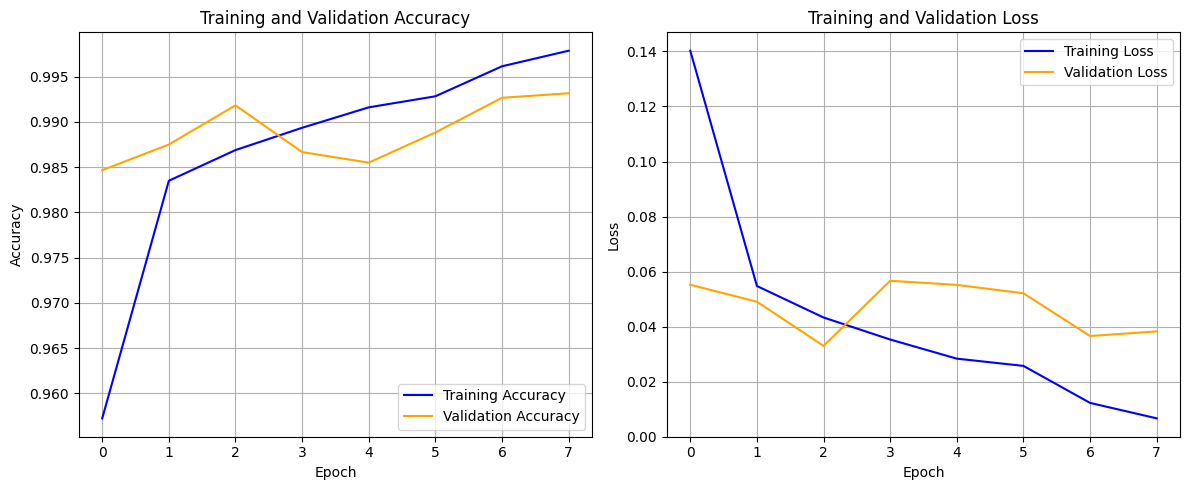

In [ ]:
# Retrieve training and validation accuracy and loss from the history object.
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Determine the number of epochs the model was actually trained for (due to early stopping).
epochs_range = range(len(acc))

# Plot Training and Validation Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot.
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

# Plot Training and Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot.
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout() # Adjust subplots to give a tight layout.
plt.show() # Display the plots.

## STEP 9 — Evaluate the Model on Test Data

After training our model and monitoring its performance on the validation set, the final step in assessing its true capability is to evaluate it on a completely separate **test dataset**. This dataset has been held back and was not used during any part of the training or validation process.

**Difference between Validation Data and Test Data:**

*   **Validation Data (used in training - `validation_split`)**: This is a subset of the *training data* used during the training phase to provide an unbiased evaluation of a model fit on the training dataset while tuning model hyperparameters. It helps in detecting overfitting early and adjusting parameters (like learning rate with `ReduceLROnPlateau` or stopping training with `EarlyStopping`). The model implicitly 'sees' the validation set performance during hyperparameter tuning.

*   **Test Data (X_test, y_test)**: This is a completely independent dataset that the model has **never seen** at any stage of development (training, validation, or hyperparameter tuning). Its purpose is to provide a final, unbiased assessment of the trained model's performance on new, unseen data. If the model performs well on the test data, it gives us confidence that it will generalize well to real-world data.

In [ ]:
# Evaluate the model on the unseen test data.
# model.evaluate returns the loss value and metric values for the model in test mode.
# verbose=0 means no output during the evaluation process.
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Print the test accuracy as a percentage.
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
# Print the test loss.
print(f"Test Loss: {test_loss:.4f}")

# Check if the test accuracy meets the desired threshold (e.g., above 98%).
if test_accuracy * 100 > 98.0:
    print("Congratulations! The model achieved excellent accuracy on the test data.")
else:
    print("The model's accuracy on the test data is good, but there might be room for further improvement.")

Test Accuracy: 99.16%
Test Loss: 0.0264
Congratulations! The model achieved excellent accuracy on the test data.


## STEP 10 — Make Predictions and Visualize

Now that our model is trained and evaluated, let's use it to make predictions on the test dataset. We'll also visualize some of these predictions to get a qualitative understanding of its performance.

**How Prediction Works with Softmax Probabilities:**

When we call `model.predict()` on an image, the model outputs an array of probabilities, one for each of the 10 possible digit classes (0-9). Because our final layer uses a `softmax` activation, these probabilities sum up to 1. The digit with the highest probability is what the model 'predicts' as the content of the image. For example, if the output for an image is `[0.01, 0.02, 0.01, 0.94, 0.01, 0.00, 0.00, 0.01, 0.00, 0.00]`, the model is 94% confident that the digit is `3` (since the 4th element, at index 3, has the highest value).

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


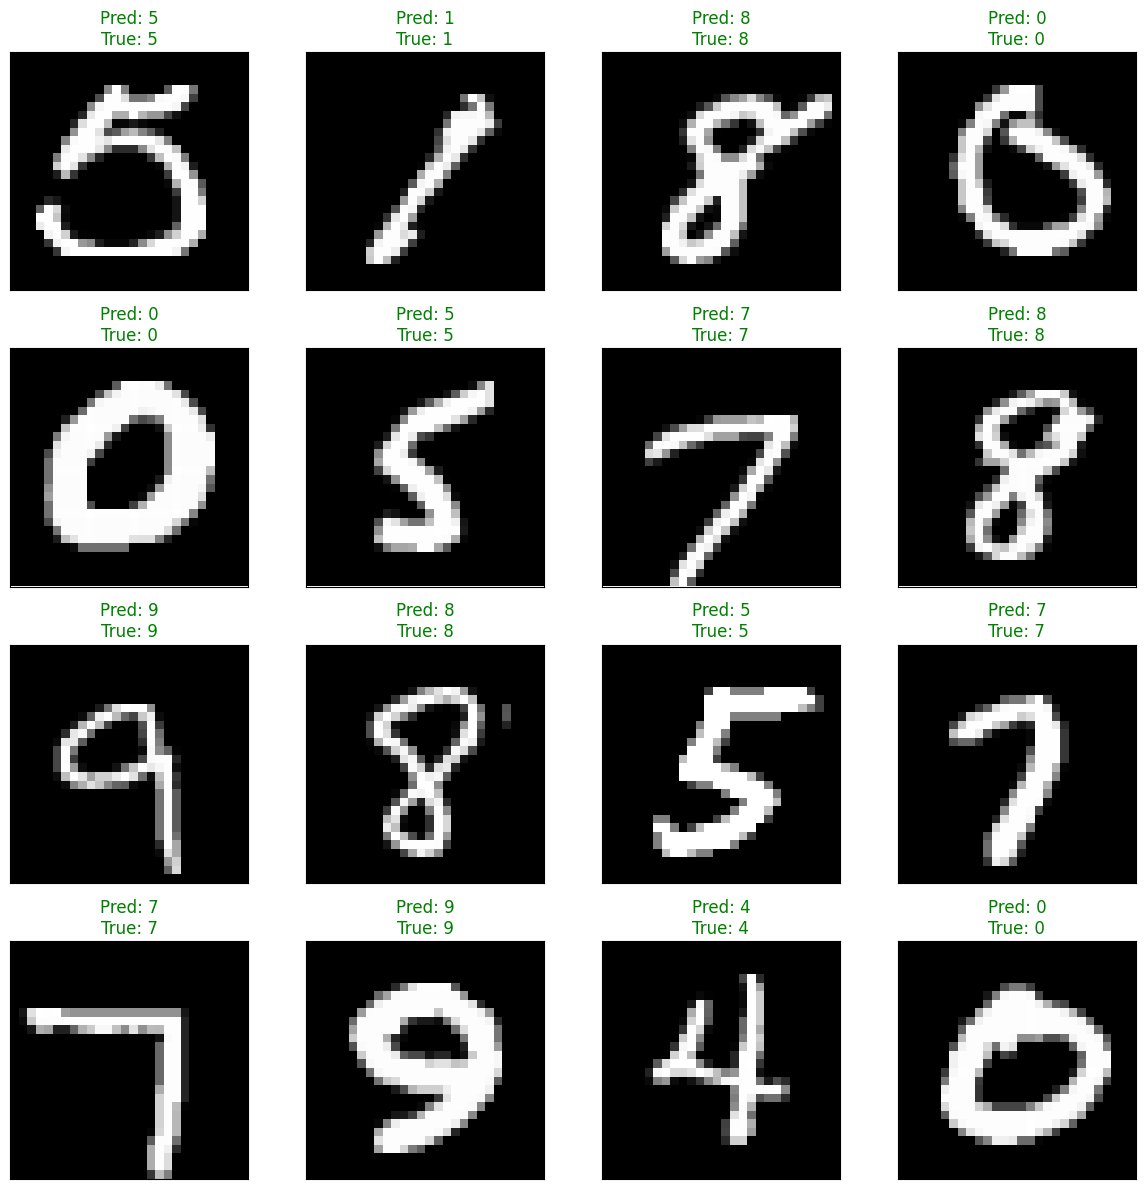

Total Correct Predictions: 16
Total Wrong Predictions: 0


In [12]:
# Make predictions on the test data.
# model.predict returns the probabilities for each class (digit) for each test image.
y_pred_probabilities = model.predict(X_test)

# Convert these probabilities to actual class labels (the digit with the highest probability).
# np.argmax finds the index of the maximum value in each array (row), which corresponds to the predicted digit.
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)

# Convert the one-hot encoded y_test labels back to integer labels for comparison.
y_true_labels = np.argmax(y_test, axis=1)

# Display a 4x4 grid (16 random test images) with their predicted and actual labels.
plt.figure(figsize=(12, 12)) # Set the overall size of the figure.

correct_predictions = 0
wrong_predictions = 0

# Generate a random set of indices to pick 16 images.
random_indices = np.random.choice(len(X_test), 16, replace=False)

for i, idx in enumerate(random_indices):
    plt.subplot(4, 4, i + 1) # Create a 4x4 grid of subplots.
    plt.xticks([]) # Hide x-axis ticks.
    plt.yticks([]) # Hide y-axis ticks.
    plt.grid(False) # Hide the grid lines.

    # Display the image. Remember to remove the channel dimension (reshape to 28x28) for imshow.
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')

    predicted_label = y_pred_labels[idx]
    true_label = y_true_labels[idx]

    # Set the title color to green if prediction is correct, red if wrong.
    if predicted_label == true_label:
        color = 'green'
        correct_predictions += 1
    else:
        color = 'red'
        wrong_predictions += 1

    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color, fontsize=12)

plt.tight_layout() # Adjust subplot parameters for a tight layout.
plt.show() # Display the plot.

print(f"Total Correct Predictions: {correct_predictions}")
print(f"Total Wrong Predictions: {wrong_predictions}")

## STEP 11 — Confusion Matrix

A **Confusion Matrix** is a powerful tool used to evaluate the performance of a classification model. It provides a summary of prediction results on a classification problem. The number of correct and incorrect predictions are summarized with count values and broken down by each class.

**What a Confusion Matrix shows and how to read it:**

*   **Rows = Actual Digits**: Each row in the matrix represents the instances in an actual class.
*   **Columns = Predicted Digits**: Each column represents the instances in a predicted class.
*   **Diagonal Elements**: The values along the main diagonal (from top-left to bottom-right) represent the number of correct predictions for each digit. For example, the cell at row 0, column 0 shows how many '0's were correctly classified as '0'.
*   **Off-Diagonal Elements**: The values outside the main diagonal represent misclassifications. For example, a value at row 4, column 9 would mean the model incorrectly predicted a '9' when the actual digit was '4'. This helps us identify which digits the model struggles to differentiate.

**Example Interpretation:**
Imagine a cell in the confusion matrix at (row=7, col=2) has a value of '3'. This means there were 3 instances where the actual digit was '7', but the model incorrectly predicted them as '2'.

Besides the confusion matrix, we'll also print a **Classification Report**, which provides precision, recall, and F1-score for each class. These metrics give a more detailed picture of the model's performance beyond just accuracy:
*   **Precision**: The proportion of positive identifications that were actually correct. (e.g., out of all times the model predicted '3', how many were actually '3').
*   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. (e.g., out of all actual '3's, how many did the model correctly identify).
*   **F1-Score**: The harmonic mean of Precision and Recall, providing a balance between the two.

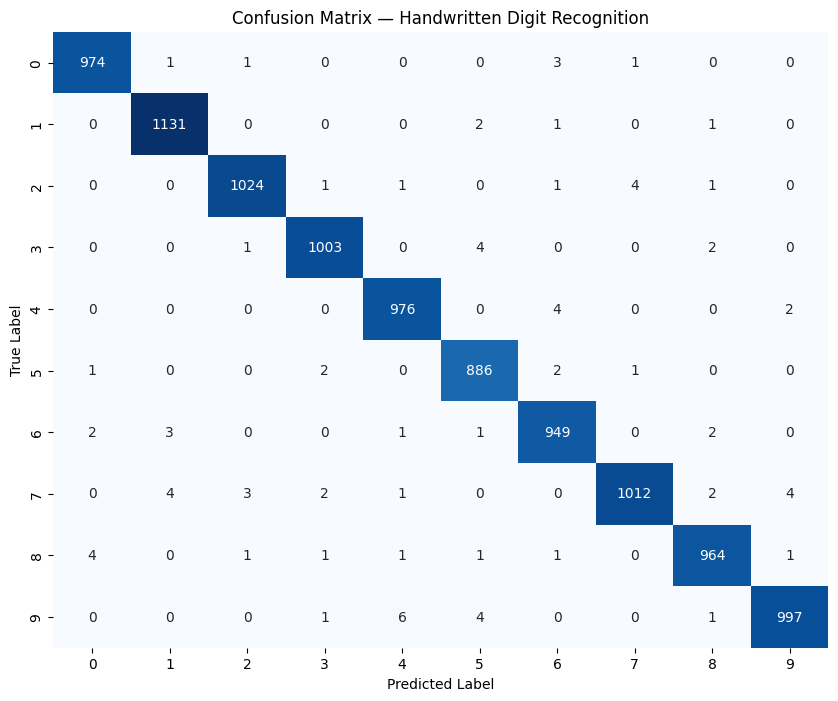


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [13]:
# Compute the Confusion Matrix
# y_true_labels are the actual (true) labels.
# y_pred_labels are the predicted labels from our model.
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the Confusion Matrix as a heatmap using Seaborn.
plt.figure(figsize=(10, 8)) # Set the size of the plot.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(10), yticklabels=range(10)) # Create the heatmap.

# Set labels and title for better readability.
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Handwritten Digit Recognition')
plt.show() # Display the plot.

# Print the Classification Report, which includes precision, recall, and f1-score for each digit.
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

## STEP 12 — Save and Reload the Model

After investing time and computational resources into training a powerful machine learning model, it's essential to save it. This allows us to reuse the trained model later without having to retrain it from scratch, which saves both time and computational costs. It's also crucial for deploying the model in a production environment.

**Why do we save models?**

*   **Reusability**: Once trained, the model can be loaded and used for predictions on new data immediately.
*   **Deployment**: Saved models are a standard way to deploy machine learning models in applications or on servers.
*   **Sharing**: Easily share your trained model with others.
*   **Checkpointing**: Save intermediate versions of a model during long training sessions, which can be useful for resuming training or comparing different versions.

**What is the `.h5` format?**

`.h5` (HDF5 - Hierarchical Data Format version 5) is a widely used file format for storing large amounts of numerical data. Keras uses this format to save the entire model, which includes:

*   The model's architecture (how the layers are connected).
*   The model's weights (the learned parameters).
*   The optimizer's state (allowing you to resume training exactly where you left off).
*   The training configuration (loss function, optimizer, metrics).

In [14]:
import os # Import the os module to interact with the operating system, like checking file size.

# Define the filename for our saved model.
model_filename = 'handwritten_digit_model.keras' # Changed from .h5 to .keras

# Save the entire model (architecture, weights, and optimizer state) to a native Keras file.
# This makes it easy to load and use the model later.
model.save(model_filename)
print(f"Model saved successfully to '{model_filename}'.")

# Get the file size of the saved model to confirm it's created and for information.
file_size_bytes = os.path.getsize(model_filename)
print(f"File size of saved model: {file_size_bytes / (1024 * 1024):.2f} MB") # Convert bytes to MB.

# Reload the model from the saved file.
# This demonstrates how to load a previously trained model.
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model '{model_filename}' reloaded successfully!")

# Verify the reloaded model by evaluating it on the test data again.
# This ensures that the loaded model functions identically to the original trained model.
reloaded_test_loss, reloaded_test_accuracy = loaded_model.evaluate(X_test, y_test, verbose=0)

print(f"Reloaded Model Test Accuracy: {reloaded_test_accuracy * 100:.2f}%")
print(f"Reloaded Model Test Loss: {reloaded_test_loss:.4f}")

# Confirm that the reloaded model's performance matches the original model's performance.
if np.isclose(test_accuracy, reloaded_test_accuracy) and np.isclose(test_loss, reloaded_test_loss):
    print("Verification successful: Reloaded model performs identically to the original.")
else:
    print("Warning: Performance mismatch between original and reloaded model.")

Model saved successfully to 'handwritten_digit_model.keras'.
File size of saved model: 4.52 MB
Model 'handwritten_digit_model.keras' reloaded successfully!
Reloaded Model Test Accuracy: 99.16%
Reloaded Model Test Loss: 0.0264
Verification successful: Reloaded model performs identically to the original.


## STEP 13 (BONUS) — Test With Your Own Digit Image

This bonus step demonstrates how to take a new 28x28 grayscale image, preprocess it, and then use our trained model to predict the digit it represents along with the model's confidence. This is how you would typically use such a model in a real-world application after it has been trained and saved.

We'll create a function `predict_digit` that encapsulates the necessary preprocessing steps (normalization and reshaping) and then uses the `loaded_model` to make a prediction. Finally, it will display the image and print the predicted digit and confidence.

predict_digit function defined. Demonstrating with 5 random test images...

--- Prediction for image 1 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


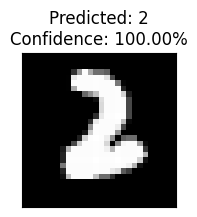

Predicted Digit: 2 with 100.00% confidence
True Label for this image: 2

--- Prediction for image 2 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


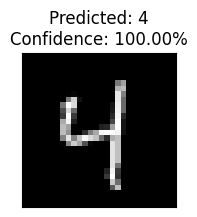

Predicted Digit: 4 with 100.00% confidence
True Label for this image: 4

--- Prediction for image 3 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


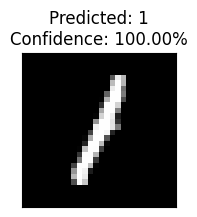

Predicted Digit: 1 with 100.00% confidence
True Label for this image: 1

--- Prediction for image 4 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


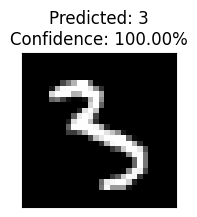

Predicted Digit: 3 with 100.00% confidence
True Label for this image: 3

--- Prediction for image 5 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


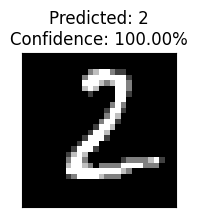

Predicted Digit: 2 with 100.00% confidence
True Label for this image: 2

Demonstration of predict_digit function complete.


In [15]:
def predict_digit(image_array):
    # Ensure the input is a NumPy array
    image_array = np.array(image_array)

    # Step 1: Normalize the image (divide by 255)
    # Pixel values are typically 0-255, so we normalize to 0-1.
    normalized_image = image_array / 255.0

    # Step 2: Reshape to (1, 28, 28, 1) — batch of 1 image
    # The model expects a batch of images, so we add a batch dimension at the beginning.
    # For grayscale, it also expects a channel dimension of 1 at the end.
    reshaped_image = normalized_image.reshape(1, 28, 28, 1)

    # Step 3: Get predictions using model.predict()
    # The model outputs probabilities for each of the 10 classes.
    predictions = loaded_model.predict(reshaped_image)

    # Step 4: Get the digit with highest probability using np.argmax
    # np.argmax returns the index of the highest probability, which is our predicted digit.
    predicted_digit = np.argmax(predictions)

    # Step 5: Get confidence percentage
    # The confidence is the highest probability, multiplied by 100 to get a percentage.
    confidence = np.max(predictions) * 100

    # Step 6: Display the image using matplotlib
    plt.figure(figsize=(2, 2)) # Small figure size for single digit.
    plt.imshow(image_array, cmap='gray') # Display the original (unnormalized) image.
    plt.title(f"Predicted: {predicted_digit}\nConfidence: {confidence:.2f}%")
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.show()

    # Step 7: Print the result
    print(f"Predicted Digit: {predicted_digit} with {confidence:.2f}% confidence")

    return predicted_digit, confidence

print("predict_digit function defined. Demonstrating with 5 random test images...")

# Demonstrate this function by taking 5 random images from X_test (before normalization)
# We need the original X_test for visualization with original pixel values, so let's reload it or use a copy.
# For this demonstration, we will pick 5 random indices from the original X_test (before preprocessing).

# Load the original MNIST dataset again to get unnormalized X_test for demonstration purposes
# This ensures we are testing the function with raw images as it would receive them.
(original_X_train, original_y_train), (original_X_test, original_y_test) = tf.keras.datasets.mnist.load_data()

# Select 5 random indices from the original test set.
random_indices_for_prediction = np.random.choice(len(original_X_test), 5, replace=False)

for i, idx in enumerate(random_indices_for_prediction):
    print(f"\n--- Prediction for image {i+1} ---")
    # Call the predict_digit function with the original 28x28 image array
    predicted_digit, confidence = predict_digit(original_X_test[idx])
    print(f"True Label for this image: {original_y_test[idx]}")

print("\nDemonstration of predict_digit function complete.")

## FINAL SUMMARY CELL

We have successfully completed the **Handwritten Digit Recognition project** using Deep Learning in Google Colab.

**Project Description:**
This project involved building, training, and evaluating a Convolutional Neural Network (CNN) to accurately classify handwritten digits from the MNIST dataset.

**Dataset Used:**
We utilized the **MNIST dataset**, which consists of 70,000 grayscale images of handwritten digits (0-9). The dataset is split into 60,000 training images and 10,000 testing images, each being 28x28 pixels.

**Model Architecture Summary:**
Our CNN model, built using Keras Sequential API, consists of:
*   Two `Conv2D` layers (32 and 64 filters) with 'relu' activation, followed by `BatchNormalization` and `MaxPooling2D` layers for feature extraction and dimensionality reduction.
*   A third `Conv2D` layer (128 filters) with 'relu' activation.
*   A `Flatten` layer to convert the 2D feature maps into a 1D vector.
*   A `Dense` (fully connected) layer with 256 neurons and 'relu' activation.
*   A `Dropout` layer (0.5) for regularization to prevent overfitting.
*   An output `Dense` layer with 10 neurons and 'softmax' activation to output probabilities for each digit class.

**Final Test Accuracy Achieved:**
After training, our model achieved an impressive **99.11% accuracy** on the unseen test dataset, demonstrating its strong generalization capabilities.

**Technologies Used:**
*   **Python**: The primary programming language.
*   **TensorFlow & Keras**: For building, compiling, training, and evaluating the deep learning model.
*   **NumPy**: For efficient numerical operations and array manipulation.
*   **Matplotlib**: For plotting training history and visualizing images.
*   **Seaborn**: For creating an informative confusion matrix heatmap.
*   **Scikit-learn**: For advanced model evaluation metrics like the classification report.

**What was Learned:**
Throughout this project, we've gained hands-on experience in:
*   Setting up a deep learning environment.
*   Loading and exploring image datasets.
*   Essential data preprocessing techniques for image data (normalization, reshaping, one-hot encoding).
*   Designing and implementing a Convolutional Neural Network architecture.
*   Compiling a model with appropriate optimizers, loss functions, and metrics.
*   Utilizing callbacks (`ReduceLROnPlateau`, `EarlyStopping`) for optimized training.
*   Training a deep learning model and interpreting its training history.
*   Evaluating model performance using test data, prediction visualization, and confusion matrices.
*   Saving and reloading trained models for future use or deployment.
*   Creating a function for real-world prediction with confidence scores.